<a href="https://colab.research.google.com/github/RayenMalouche/ML-OPS-Molka-Rayen/blob/main/transformers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Transformer Training Script - Google Colab Compatible
Run this on Colab for GPU acceleration
#Training


Install dependencies (une seule fois)


In [ ]:
!pip install -q transformers datasets torch scikit-learn matplotlib seaborn mlflow accelerate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.4/80.4 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 55.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 329.1/329.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.8/178.8 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 749.8/749.8 kB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.3/167.3 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 106.

Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imports

In [ ]:
import os
import torch
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)
from datasets import Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All imports successful!")
print(f"🔥 PyTorch version: {torch.__version__}")
print(f"🚀 CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"🎮 GPU: {torch.cuda.get_device_name(0)}")


✅ All imports successful!
🔥 PyTorch version: 2.8.0+cu126
🚀 CUDA available: True
🎮 GPU: Tesla T4


Configuration

In [ ]:
CONFIG = {
    # Paths (UPDATE THIS!)
    "data_path": "/content/drive/MyDrive/datasetmlops/all_tickets_cleaned.csv",
    "output_dir": "/content/drive/MyDrive/mlops_outputs/transformer",

    # Model settings
    "model_name": "distilbert-base-multilingual-cased",
    "max_length": 128,

    # Training settings
    "num_epochs": 3,
    "batch_size": 10,
    "learning_rate": 2e-5,
    "warmup_steps": 10,
    "weight_decay": 0.01,

    # Other
    "test_size": 0.2,
    "random_state": 42
}

# Create output directory
os.makedirs(CONFIG["output_dir"], exist_ok=True)
os.makedirs(f"{CONFIG['output_dir']}/plots", exist_ok=True)

print("\n📁 Output directory:", CONFIG["output_dir"])


📁 Output directory: /content/drive/MyDrive/mlops_outputs/transformer


Load Data

In [ ]:
print("\n" + "="*60)
print("📂 Loading Data")
print("="*60)

# Check if file exists
if not os.path.exists(CONFIG["data_path"]):
    raise FileNotFoundError(f"❌ Data file not found: {CONFIG['data_path']}")

# Load dataset
df = pd.read_csv(CONFIG["data_path"])
print(f"✅ Loaded {len(df)} samples")

# Validate columns
if "Document" not in df.columns or "Topic_group" not in df.columns:
    raise ValueError("❌ Dataset must contain 'Document' and 'Topic_group' columns")

# Clean data
df = df.dropna(subset=["Document", "Topic_group"])
df = df[df["Document"].str.strip() != ""]
df = df[df["Topic_group"].str.strip() != ""]

print(f"✅ After cleaning: {len(df)} samples")
print(f"\n📊 Class Distribution:")
print(df["Topic_group"].value_counts())


📂 Loading Data
✅ Loaded 47837 samples
✅ After cleaning: 47837 samples

📊 Class Distribution:
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


Prepare Data

In [ ]:
print("\n" + "="*60)
print("🔧 Preparing Data")
print("="*60)

X = df["Document"].values
y = df["Topic_group"].values

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
num_labels = len(label_encoder.classes_)

print(f"✅ Number of classes: {num_labels}")
print(f"📋 Classes: {list(label_encoder.classes_)}")

# Save label mapping
label_mapping = {
    int(i): str(label)
    for i, label in enumerate(label_encoder.classes_)
}
with open(f"{CONFIG['output_dir']}/label_mapping.json", "w") as f:
    json.dump(label_mapping, f, indent=2)

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y_encoded
)

print(f"✅ Train samples: {len(X_train)}")
print(f"✅ Test samples: {len(X_test)}")


🔧 Preparing Data
✅ Number of classes: 8
📋 Classes: ['Access', 'Administrative rights', 'HR Support', 'Hardware', 'Internal Project', 'Miscellaneous', 'Purchase', 'Storage']
✅ Train samples: 38269
✅ Test samples: 9568


Create Datasets

In [ ]:
print("\n" + "="*60)
print("🔤 Tokenizing Data")
print("="*60)

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])
print(f"✅ Loaded tokenizer: {CONFIG['model_name']}")

# Create HuggingFace datasets
train_dataset = Dataset.from_dict({
    "text": X_train.tolist(),
    "label": y_train.tolist()
})
test_dataset = Dataset.from_dict({
    "text": X_test.tolist(),
    "label": y_test.tolist()
})

# Tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=CONFIG["max_length"]
    )

# Apply tokenization with progress bar
print("⏳ Tokenizing training data...")
train_dataset = train_dataset.map(tokenize_function, batched=True)
print("⏳ Tokenizing test data...")
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

print("✅ Tokenization complete!")


🔤 Tokenizing Data


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

✅ Loaded tokenizer: distilbert-base-multilingual-cased
⏳ Tokenizing training data...


Map:   0%|          | 0/38269 [00:00<?, ? examples/s]

⏳ Tokenizing test data...


Map:   0%|          | 0/9568 [00:00<?, ? examples/s]

✅ Tokenization complete!


Load Model

In [ ]:
print("\n" + "="*60)
print("🤖 Loading Model")
print("="*60)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device: {device}")

model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=num_labels
)
model.to(device)

print(f"✅ Model loaded with {num_labels} output classes")


🤖 Loading Model
🚀 Device: cuda


model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-multilingual-cased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Model loaded with 8 output classes


Define Metrics

In [ ]:
def compute_metrics(pred):
    """Compute evaluation metrics"""
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    acc = accuracy_score(labels, preds)
    f1 = f1_score(labels, preds, average="weighted")

    return {"accuracy": acc, "f1": f1}

Training Configuration

In [ ]:
print("\n" + "="*60)
print("⚙️ Training Configuration")
print("="*60)

training_args = TrainingArguments(
    output_dir=CONFIG["output_dir"],
    num_train_epochs=CONFIG["num_epochs"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["batch_size"],
    learning_rate=CONFIG["learning_rate"],
    warmup_steps=CONFIG["warmup_steps"],
    weight_decay=CONFIG["weight_decay"],
    logging_dir=f"{CONFIG['output_dir']}/logs",
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    push_to_hub=False,
    report_to=["none"],
    fp16=torch.cuda.is_available(),  # Mixed precision if GPU available
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=7)]
)

print("✅ Trainer initialized")


⚙️ Training Configuration
✅ Trainer initialized


Train Model

In [ ]:
print("\n" + "="*60)
print("🏋️ Training Started")
print("="*60)

train_result = trainer.train()

print("\n✅ Training complete!")
print(f"📊 Training loss: {train_result.training_loss:.4f}")


🏋️ Training Started


Step,Training Loss,Validation Loss,Accuracy,F1
200,1.470400,1.281291,0.567830,0.513101
400,0.878500,0.801921,0.757212,0.754573
600,0.811200,0.679116,0.782609,0.784698
800,0.560900,0.596347,0.807797,0.808484
1000,0.608400,0.633561,0.793478,0.797461
1200,0.632600,0.534035,0.822115,0.821481
1400,0.594600,0.550999,0.823788,0.824903


Step,Training Loss,Validation Loss,Accuracy,F1
200,1.470400,1.281291,0.567830,0.513101
400,0.878500,0.801921,0.757212,0.754573
600,0.811200,0.679116,0.782609,0.784698
800,0.560900,0.596347,0.807797,0.808484
1000,0.608400,0.633561,0.793478,0.797461
1200,0.632600,0.534035,0.822115,0.821481
1400,0.594600,0.550999,0.823788,0.824903
1600,0.458200,0.516319,0.834657,0.835230
1800,0.548000,0.529642,0.832358,0.831576
2000,0.441500,0.552075,0.829536,0.830020



✅ Training complete!
📊 Training loss: 0.4246


Evaluate Model

In [ ]:
print("\n" + "="*60)
print("📊 Evaluation")
print("="*60)

eval_result = trainer.evaluate()

print(f"✅ Accuracy: {eval_result['eval_accuracy']:.4f}")
print(f"✅ F1 Score: {eval_result['eval_f1']:.4f}")
print(f"✅ Loss: {eval_result['eval_loss']:.4f}")

# Save results
results = {
    "train_loss": train_result.training_loss,
    "eval_accuracy": eval_result['eval_accuracy'],
    "eval_f1": eval_result['eval_f1'],
    "eval_loss": eval_result['eval_loss'],
    "config": CONFIG
}

with open(f"{CONFIG['output_dir']}/training_results.json", "w") as f:
    json.dump(results, f, indent=2)


📊 Evaluation


✅ Accuracy: 0.8843
✅ F1 Score: 0.8843
✅ Loss: 0.4460


Save Model

In [ ]:
print("\n" + "="*60)
print("💾 Saving Model")
print("="*60)

model_save_path = f"{CONFIG['output_dir']}/final_model"
trainer.save_model(model_save_path)
tokenizer.save_pretrained(model_save_path)

print(f"✅ Model saved to: {model_save_path}")


💾 Saving Model
✅ Model saved to: /content/drive/MyDrive/mlops_outputs/transformer/final_model


Generate Predictions

In [ ]:
print("\n" + "="*60)
print("🔮 Generating Predictions")
print("="*60)

predictions = trainer.predict(test_dataset)
y_pred = predictions.predictions.argmax(-1)

print("✅ Predictions generated")


🔮 Generating Predictions


✅ Predictions generated


Visualizations


📊 Creating Visualizations
⏳ Creating confusion matrix...


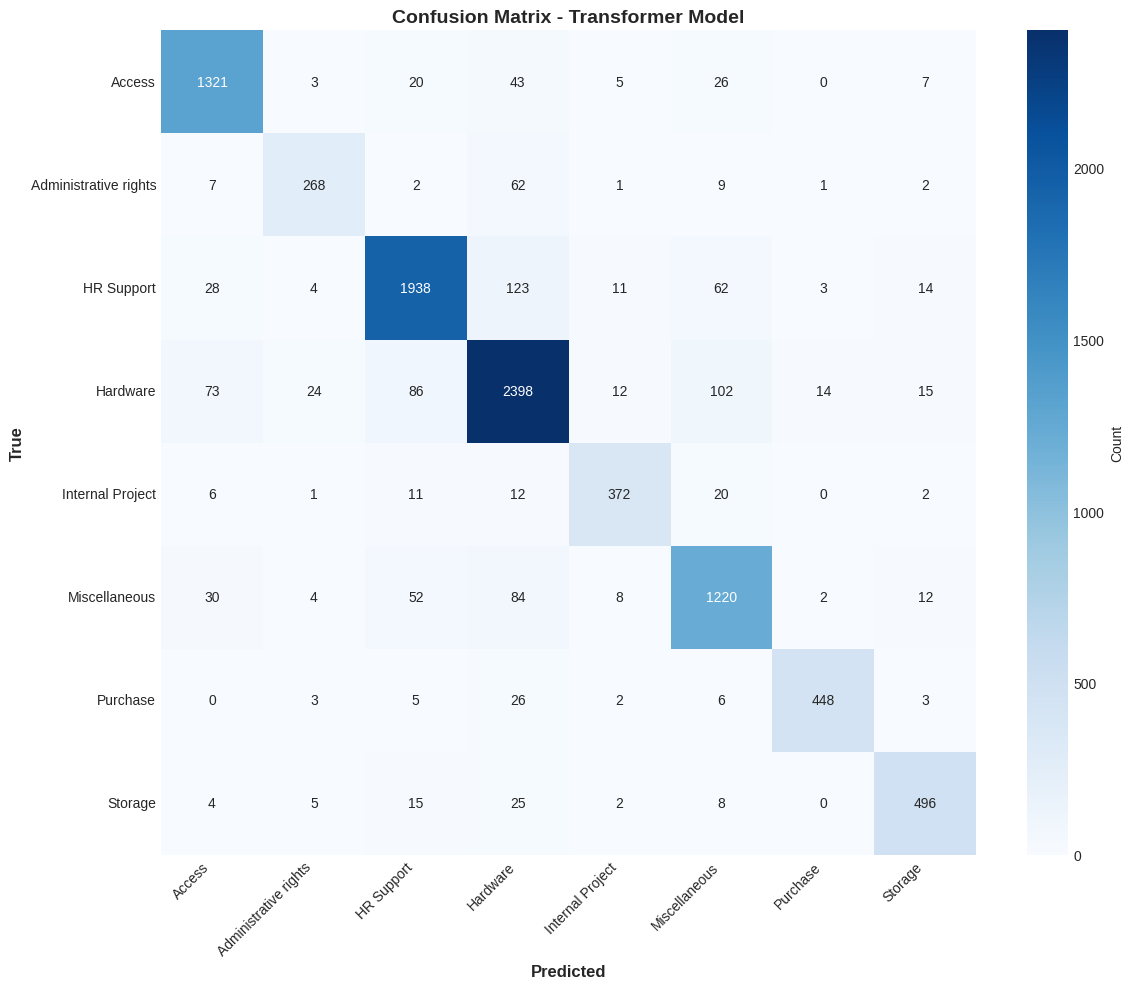

✅ Saved: /content/drive/MyDrive/mlops_outputs/transformer/plots/confusion_matrix.png
⏳ Creating class distribution plot...


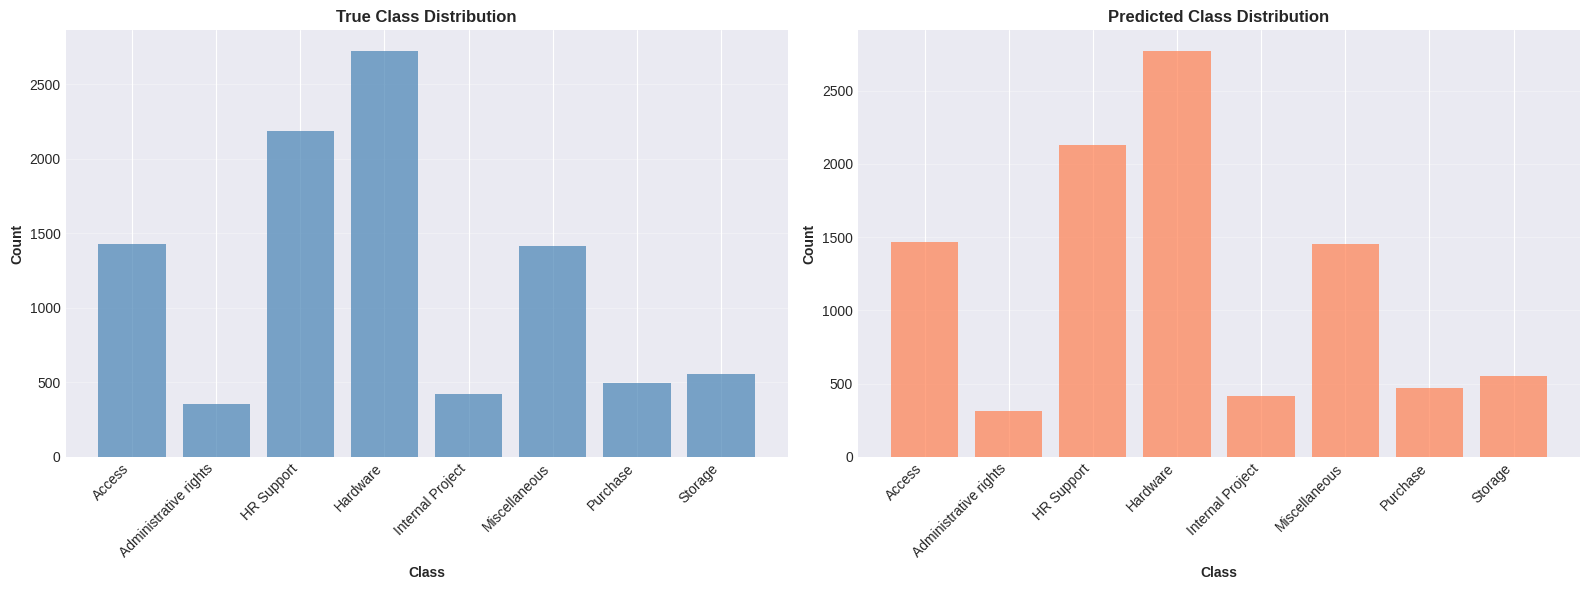

✅ Saved: /content/drive/MyDrive/mlops_outputs/transformer/plots/class_distribution.png
⏳ Creating per-class performance plot...


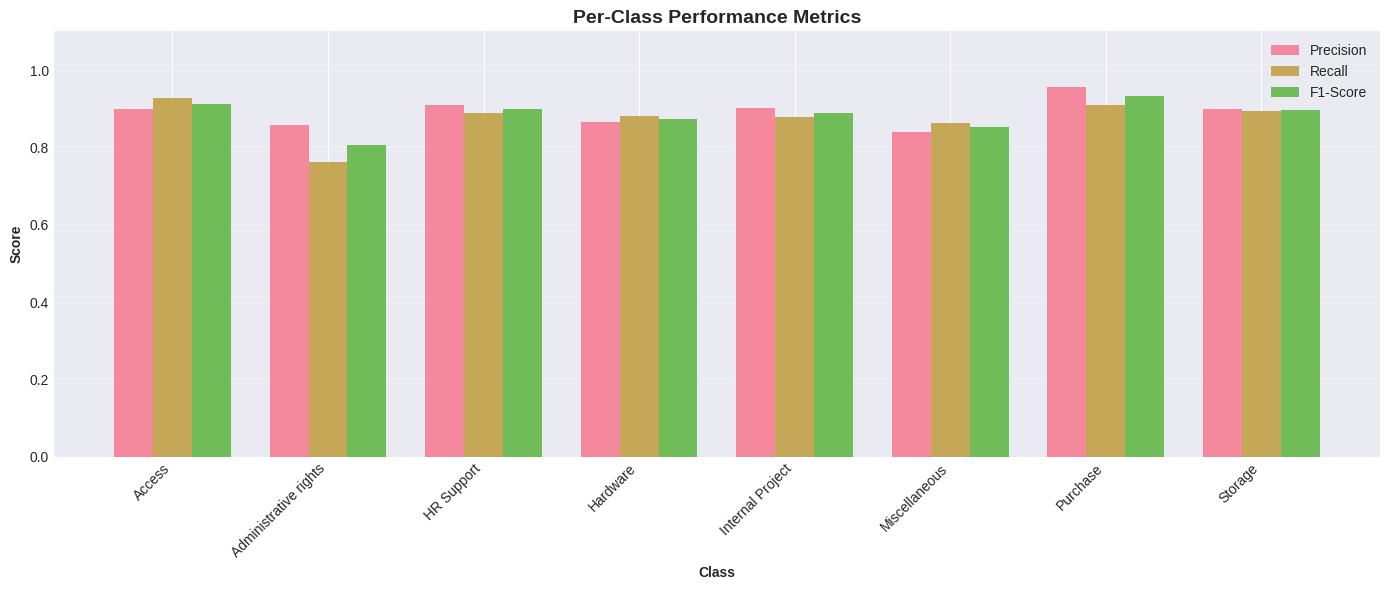

✅ Saved: /content/drive/MyDrive/mlops_outputs/transformer/plots/per_class_performance.png


In [ ]:
print("\n" + "="*60)
print("📊 Creating Visualizations")
print("="*60)

# 1. Confusion Matrix
print("⏳ Creating confusion matrix...")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
    cbar_kws={'label': 'Count'}
)
plt.xlabel("Predicted", fontsize=12, fontweight='bold')
plt.ylabel("True", fontsize=12, fontweight='bold')
plt.title("Confusion Matrix - Transformer Model", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
cm_path = f"{CONFIG['output_dir']}/plots/confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✅ Saved: {cm_path}")

# 2. Class Distribution Comparison
print("⏳ Creating class distribution plot...")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# True distribution
true_counts = pd.Series(y_test).value_counts().sort_index()
axes[0].bar(range(len(true_counts)), true_counts.values, color='steelblue', alpha=0.7)
axes[0].set_xticks(range(len(label_encoder.classes_)))
axes[0].set_xticklabels(label_encoder.classes_, rotation=45, ha='right')
axes[0].set_title("True Class Distribution", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Class", fontweight='bold')
axes[0].set_ylabel("Count", fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Predicted distribution
pred_counts = pd.Series(y_pred).value_counts().sort_index()
axes[1].bar(range(len(pred_counts)), pred_counts.values, color='coral', alpha=0.7)
axes[1].set_xticks(range(len(label_encoder.classes_)))
axes[1].set_xticklabels(label_encoder.classes_, rotation=45, ha='right')
axes[1].set_title("Predicted Class Distribution", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Class", fontweight='bold')
axes[1].set_ylabel("Count", fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
dist_path = f"{CONFIG['output_dir']}/plots/class_distribution.png"
plt.savefig(dist_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✅ Saved: {dist_path}")

# 3. Per-Class Performance
print("⏳ Creating per-class performance plot...")
report = classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_,
    output_dict=True
)

# Extract metrics for each class
classes = label_encoder.classes_
precision = [report[c]['precision'] for c in classes]
recall = [report[c]['recall'] for c in classes]
f1_scores = [report[c]['f1-score'] for c in classes]

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width, precision, width, label='Precision', alpha=0.8)
ax.bar(x, recall, width, label='Recall', alpha=0.8)
ax.bar(x + width, f1_scores, width, label='F1-Score', alpha=0.8)

ax.set_xlabel('Class', fontweight='bold')
ax.set_ylabel('Score', fontweight='bold')
ax.set_title('Per-Class Performance Metrics', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim([0, 1.1])

plt.tight_layout()
perf_path = f"{CONFIG['output_dir']}/plots/per_class_performance.png"
plt.savefig(perf_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✅ Saved: {perf_path}")

Save Reports

In [ ]:
print("\n" + "="*60)
print("📋 Saving Reports")
print("="*60)

# Classification report
report_df = pd.DataFrame(report).transpose()
report_path = f"{CONFIG['output_dir']}/classification_report.csv"
report_df.to_csv(report_path)
print(f"✅ Saved: {report_path}")

# Print classification report
print("\n" + "="*60)
print("📊 Classification Report")
print("="*60)
print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))


📋 Saving Reports
✅ Saved: /content/drive/MyDrive/mlops_outputs/transformer/classification_report.csv

📊 Classification Report
                       precision    recall  f1-score   support

               Access       0.90      0.93      0.91      1425
Administrative rights       0.86      0.76      0.81       352
           HR Support       0.91      0.89      0.90      2183
             Hardware       0.86      0.88      0.87      2724
     Internal Project       0.90      0.88      0.89       424
        Miscellaneous       0.84      0.86      0.85      1412
             Purchase       0.96      0.91      0.93       493
              Storage       0.90      0.89      0.90       555

             accuracy                           0.88      9568
            macro avg       0.89      0.88      0.88      9568
         weighted avg       0.88      0.88      0.88      9568



Summary

In [ ]:
print("\n" + "="*60)
print("🎉 TRAINING COMPLETE!")
print("="*60)
print(f"📊 Final Results:")
print(f"   • Accuracy: {eval_result['eval_accuracy']:.4f}")
print(f"   • F1 Score: {eval_result['eval_f1']:.4f}")
print(f"   • Loss: {eval_result['eval_loss']:.4f}")
print(f"\n📁 All outputs saved to: {CONFIG['output_dir']}")
print("="*60)


🎉 TRAINING COMPLETE!
📊 Final Results:
   • Accuracy: 0.8843
   • F1 Score: 0.8843
   • Loss: 0.4460

📁 All outputs saved to: /content/drive/MyDrive/mlops_outputs/transformer


# FastAPI

Install Dependencies


In [ ]:
# 1. Install
!pip install -q fastapi uvicorn pyngrok nest-asyncio transformers torch

from google.colab import userdata
# 2. Set ngrok token (DO THIS ONCE)
from pyngrok import ngrok
NGROK_AUTH_TOKEN = userdata.get('NGROK_TOKEN')
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

# 3. Apply nest_asyncio
import nest_asyncio
nest_asyncio.apply()

Imports

In [ ]:
import os
import json
import time
from typing import Dict
from datetime import datetime

import torch
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import nest_asyncio
from pyngrok import ngrok
import uvicorn


Configuration

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/mlops_outputs/transformer/final_model"
LABEL_MAPPING_PATH = "/content/drive/MyDrive/mlops_outputs/transformer/label_mapping.json"
MAX_LENGTH = 128
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


print(f"🔧 Configuration:")
print(f"   Model Path: {MODEL_PATH}")
print(f"   Device: {DEVICE}")


🔧 Configuration:
   Model Path: /content/drive/MyDrive/mlops_outputs/transformer/final_model
   Device: cuda
✅ ngrok authtoken configured!


Pydantic Models

In [ ]:
class PredictRequest(BaseModel):
    text: str = Field(..., min_length=1, description="Ticket text to classify")

    class Config:
        json_schema_extra = {
            "example": {
                "text": "My laptop screen is broken and needs replacement"
            }
        }

class PredictResponse(BaseModel):
    label: str
    confidence: float
    all_scores: Dict[str, float]
    model: str = "transformer"
    processing_time: float
    timestamp: str

class HealthResponse(BaseModel):
    status: str
    model_loaded: bool
    device: str
    model_path: str

FastAPI App

In [ ]:
app = FastAPI(
    title="CallCenterAI - Transformer Service (Colab)",
    description="Transformer-based ticket classification using DistilBERT",
    version="1.0.0"
)

# Global variables
model = None
tokenizer = None
label_mapping = None

Load Model

In [ ]:
def load_model():
    """Load model, tokenizer, and label mapping"""
    global model, tokenizer, label_mapping

    try:
        print(f"\n🚀 Loading model from: {MODEL_PATH}")

        # Check if path exists
        if not os.path.exists(MODEL_PATH):
            raise FileNotFoundError(f"Model path not found: {MODEL_PATH}")

        # Load tokenizer
        print("⏳ Loading tokenizer...")
        tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
        print("✅ Tokenizer loaded")

        # Load model
        print("⏳ Loading model...")
        model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
        model.to(DEVICE)
        model.eval()
        print(f"✅ Model loaded on {DEVICE}")

        # Load label mapping
        print("⏳ Loading label mapping...")
        with open(LABEL_MAPPING_PATH, 'r') as f:
            label_mapping = json.load(f)
        label_mapping = {int(k): v for k, v in label_mapping.items()}
        print(f"✅ Label mapping loaded: {len(label_mapping)} classes")
        print(f"📋 Classes: {list(label_mapping.values())}")

        return True

    except Exception as e:
        print(f"❌ Error loading model: {e}")
        return False

API Endpoints

In [ ]:
@app.get("/")
async def root():
    """Root endpoint"""
    return {
        "service": "CallCenterAI - Transformer Service",
        "model": "distilbert-base-multilingual-cased",
        "version": "1.0.0",
        "status": "running",
        "endpoints": {
            "predict": "/predict",
            "health": "/health",
            "docs": "/docs"
        }
    }

@app.get("/health", response_model=HealthResponse)
async def health():
    """Health check endpoint"""
    return HealthResponse(
        status="healthy" if model is not None else "unhealthy",
        model_loaded=model is not None,
        device=DEVICE,
        model_path=MODEL_PATH
    )

@app.post("/predict", response_model=PredictResponse)
async def predict(request: PredictRequest):
    """Predict ticket category"""
    if model is None or tokenizer is None:
        raise HTTPException(status_code=503, detail="Model not loaded")

    start_time = time.time()

    try:
        # Tokenize
        inputs = tokenizer(
            request.text,
            padding="max_length",
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )

        # Move to device
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        # Predict
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits
            probs = torch.nn.functional.softmax(logits, dim=-1)
            probs = probs.cpu().numpy()[0]

        # Get results
        pred_class = int(probs.argmax())
        confidence = float(probs[pred_class])
        predicted_label = label_mapping[pred_class]

        all_scores = {
            label_mapping[i]: float(probs[i])
            for i in range(len(probs))
        }

        processing_time = time.time() - start_time

        return PredictResponse(
            label=predicted_label,
            confidence=confidence,
            all_scores=all_scores,
            processing_time=processing_time,
            timestamp=datetime.utcnow().isoformat()
        )

    except Exception as e:
        raise HTTPException(status_code=500, detail=f"Prediction error: {str(e)}")

Test the API

In [ ]:
def test_api(base_url):
    """Test the API with some examples"""
    import requests

    print("\n" + "="*60)
    print("🧪 TESTING API")
    print("="*60)

    test_cases = [
        "My laptop screen is broken and needs replacement",
        "Cannot login to my account",
        "Need help with printer setup",
        "Mon ordinateur ne démarre pas",  # French
        "Password reset needed"
    ]

    for i, text in enumerate(test_cases, 1):
        print(f"\n📝 Test {i}: {text}")
        try:
            response = requests.post(
                f"{base_url}/predict",
                json={"text": text},
                timeout=10
            )

            if response.status_code == 200:
                result = response.json()
                print(f"   ✅ Prediction: {result['label']}")
                print(f"   📊 Confidence: {result['confidence']:.4f}")
                print(f"   ⏱️  Time: {result['processing_time']:.3f}s")
            else:
                print(f"   ❌ Error: {response.status_code}")

        except Exception as e:
            print(f"   ❌ Error: {e}")

    print("\n" + "="*60)

killing a sessuion

In [ ]:
# Force-kill all ngrok processes/sessions
from pyngrok import ngrok

print("🔪 Killing all ngrok tunnels & processes...")
ngrok.kill()  # Kills local processes

# Extra: Restart ngrok subprocess (if stuck)
import subprocess
import os
try:
    subprocess.run(["pkill", "-f", "ngrok"], check=False)
    print("✅ Local ngrok processes killed")
except:
    pass

# Check for stuck sessions (logs warning)
print("⚠️  Check dashboard: https://dashboard.ngrok.com/agents")
print("   Stop any active sessions manually if needed.")

🔪 Killing all ngrok tunnels & processes...
✅ Local ngrok processes killed
⚠️  Check dashboard: https://dashboard.ngrok.com/agents
   Stop any active sessions manually if needed.


Start Server with ngrok

In [ ]:
import nest_asyncio
from pyngrok import ngrok
import uvicorn
import threading

# APPLY NESTED ASYNCIO
nest_asyncio.apply()

def start_server_with_ngrok(port=8000):
    """Start FastAPI server with ngrok tunnel in Colab"""

    # Load model
    print("\n" + "="*60)
    print("LOADING MODEL")
    print("="*60)
    if not load_model():
        print("Failed to load model. Check paths.")
        return

    # Kill existing tunnels
    ngrok.kill()

    # Start ngrok
    print("\n" + "="*60)
    print("SETTING UP NGROK")
    print("="*60)
    print("Starting ngrok tunnel...")
    public_url = ngrok.connect(port, bind_tls=True)
    print(f"ngrok tunnel established!")
    print(f"\nPublic URL: {public_url}")
    print(f"API Docs: {public_url}/docs")
    print(f"Health: {public_url}/health")
    print(f"Predict: POST {public_url}/predict")

    # Start Uvicorn in a background thread
    print("\n" + "="*60)
    print("STARTING SERVER")
    print("="*60)
    print(f"Local server: http://localhost:{port}")
    print("Server running... Use the public URL above!")
    print("Press Ctrl+C in this cell to stop")
    print("="*60 + "\n")

    def run_server():
        uvicorn.run(app, host="0.0.0.0", port=port, log_level="info")

    # Run in thread to avoid blocking
    server_thread = threading.Thread(target=run_server, daemon=True)
    server_thread.start()

    print("Server is running in background!")
    print("Open the API Docs link above to test interactively.")
    print("To stop: Restart runtime or interrupt this cell.")

    # Keep cell alive
    try:
        while True:
            time.sleep(1)
    except KeyboardInterrupt:
        print("\nStopping server...")
        ngrok.kill()

Main Execution

In [ ]:
if __name__ == "__main__":
    # Start server with ngrok
    start_server_with_ngrok(port=8000)


LOADING MODEL

🚀 Loading model from: /content/drive/MyDrive/mlops_outputs/transformer/final_model
⏳ Loading tokenizer...
✅ Tokenizer loaded
⏳ Loading model...
✅ Model loaded on cuda
⏳ Loading label mapping...
✅ Label mapping loaded: 8 classes
📋 Classes: ['Access', 'Administrative rights', 'HR Support', 'Hardware', 'Internal Project', 'Miscellaneous', 'Purchase', 'Storage']

SETTING UP NGROK
Starting ngrok tunnel...
ngrok tunnel established!

Public URL: NgrokTunnel: "https://badf0cca9cd1.ngrok-free.app" -> "http://localhost:8000"
API Docs: NgrokTunnel: "https://badf0cca9cd1.ngrok-free.app" -> "http://localhost:8000"/docs
Health: NgrokTunnel: "https://badf0cca9cd1.ngrok-free.app" -> "http://localhost:8000"/health
Predict: POST NgrokTunnel: "https://badf0cca9cd1.ngrok-free.app" -> "http://localhost:8000"/predict

STARTING SERVER
Local server: http://localhost:8000
Server running... Use the public URL above!
Press Ctrl+C in this cell to stop

Server is running in background!
Open the API

INFO:     Started server process [311]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://0.0.0.0:8000 (Press CTRL+C to quit)


INFO:     41.62.174.193:0 - "POST /predict HTTP/1.1" 200 OK


/tmp/ipython-input-1088384636.py:71: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  timestamp=datetime.utcnow().isoformat()


INFO:     41.62.174.193:0 - "GET /health HTTP/1.1" 200 OK
INFO:     41.62.174.193:0 - "GET /docs HTTP/1.1" 200 OK

Stopping server...


# Testing .0

imports


In [ ]:

import os
import json
import time
from typing import Dict, List, Optional
from datetime import datetime

import torch
import uvicorn
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel, Field
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from prometheus_client import Counter, Histogram, Gauge, generate_latest
from fastapi.responses import Response

config


In [ ]:
# ==================== Configuration ====================
MODEL_PATH = os.getenv("MODEL_PATH", "/content/drive/MyDrive/mlops_outputs/transformer/final_model")
LABEL_MAPPING_PATH = os.getenv("LABEL_MAPPING_PATH", "/content/drive/MyDrive/mlops_outputs/transformer/label_mapping.json")
MAX_LENGTH = int(os.getenv("MAX_LENGTH", "128"))
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

Prometheus Metrics

In [ ]:
# ==================== Prometheus Metrics ====================
from prometheus_client import Counter, Histogram, CollectorRegistry

# Create a custom registry
registry = CollectorRegistry()

prediction_counter = Counter(
    'transformer_predictions_total',
    'Total number of predictions made',
    registry=registry
)

prediction_duration = Histogram(
    'transformer_prediction_duration_seconds',
    'Time spent making predictions',
    registry=registry
)

Pydantic Models

In [ ]:
# ==================== Pydantic Models ====================
class PredictRequest(BaseModel):
    text: str = Field(..., min_length=1, description="Ticket text to classify")

    class Config:
        json_schema_extra = {
            "example": {
                "text": "My laptop screen is broken and needs replacement"
            }
        }

class PredictResponse(BaseModel):
    label: str = Field(..., description="Predicted category")
    confidence: float = Field(..., description="Confidence score (0-1)")
    all_scores: Dict[str, float] = Field(..., description="Scores for all categories")
    model: str = Field(default="transformer", description="Model used")
    processing_time: float = Field(..., description="Processing time in seconds")
    timestamp: str = Field(..., description="Prediction timestamp")

class HealthResponse(BaseModel):
    status: str
    model_loaded: bool
    device: str
    model_path: str


FastAPI App

In [ ]:
# ==================== FastAPI App ====================
app = FastAPI(
    title="CallCenterAI - Transformer Service",
    description="Transformer-based ticket classification using DistilBERT multilingual",
    version="1.0.0"
)

# Global variables for model and tokenizer
model = None
tokenizer = None
label_mapping = None

Startup/Shutdown

In [ ]:
# ==================== Startup/Shutdown ====================
@app.on_event("startup")
async def load_model():
    """Load model, tokenizer, and label mapping on startup"""
    global model, tokenizer, label_mapping

    try:
        print(f"🚀 Loading model from: {MODEL_PATH}")
        print(f"📱 Device: {DEVICE}")

        # Load tokenizer
        tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
        print("✅ Tokenizer loaded")

        # Load model
        model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
        model.to(DEVICE)
        model.eval()  # Set to evaluation mode
        print(f"✅ Model loaded on {DEVICE}")

        # Load label mapping
        with open(LABEL_MAPPING_PATH, 'r') as f:
            label_mapping = json.load(f)
        # Convert keys to integers
        label_mapping = {int(k): v for k, v in label_mapping.items()}
        print(f"✅ Label mapping loaded: {len(label_mapping)} classes")
        print(f"📋 Classes: {list(label_mapping.values())}")

        model_loaded.set(1)
        print("✅ Transformer service ready!")

    except Exception as e:
        print(f"❌ Error loading model: {e}")
        model_loaded.set(0)
        raise

@app.on_event("shutdown")
async def shutdown():
    """Cleanup on shutdown"""
    print("🛑 Shutting down Transformer service...")
    model_loaded.set(0)


/tmp/ipython-input-3832904960.py:2: DeprecationWarning: 
        on_event is deprecated, use lifespan event handlers instead.

        Read more about it in the
        [FastAPI docs for Lifespan Events](https://fastapi.tiangolo.com/advanced/events/).
        
  @app.on_event("startup")
/tmp/ipython-input-3832904960.py:37: DeprecationWarning: 
        on_event is deprecated, use lifespan event handlers instead.

        Read more about it in the
        [FastAPI docs for Lifespan Events](https://fastapi.tiangolo.com/advanced/events/).
        
  @app.on_event("shutdown")


Endpoints

In [ ]:
# ==================== Endpoints ====================
@app.get("/", response_model=Dict[str, str])
async def root():
    """Root endpoint with service info"""
    return {
        "service": "CallCenterAI - Transformer Service",
        "model": "distilbert-base-multilingual-cased",
        "version": "1.0.0",
        "endpoints": {
            "predict": "/predict",
            "health": "/health",
            "metrics": "/metrics"
        }
    }

@app.get("/health", response_model=HealthResponse)
async def health():
    """Health check endpoint"""
    return HealthResponse(
        status="healthy" if model is not None else "unhealthy",
        model_loaded=model is not None,
        device=DEVICE,
        model_path=MODEL_PATH
    )

@app.post("/predict", response_model=PredictResponse)
async def predict(request: PredictRequest):
    """
    Predict ticket category using Transformer model

    Args:
        request: PredictRequest with ticket text

    Returns:
        PredictResponse with predicted label, confidence, and all scores
    """
    if model is None or tokenizer is None:
        error_counter.labels(error_type="model_not_loaded").inc()
        raise HTTPException(status_code=503, detail="Model not loaded")

    start_time = time.time()

    try:
        # Tokenize input
        inputs = tokenizer(
            request.text,
            padding="max_length",
            truncation=True,
            max_length=MAX_LENGTH,
            return_tensors="pt"
        )

        # Move to device
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        # Make prediction
        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits

            # Apply softmax to get probabilities
            probs = torch.nn.functional.softmax(logits, dim=-1)
            probs = probs.cpu().numpy()[0]

        # Get predicted class
        pred_class = int(probs.argmax())
        confidence = float(probs[pred_class])
        predicted_label = label_mapping[pred_class]

        # Get all scores
        all_scores = {
            label_mapping[i]: float(probs[i])
            for i in range(len(probs))
        }

        # Calculate processing time
        processing_time = time.time() - start_time

        # Update metrics
        prediction_counter.inc()
        prediction_duration.observe(processing_time)

        return PredictResponse(
            label=predicted_label,
            confidence=confidence,
            all_scores=all_scores,
            model="transformer",
            processing_time=processing_time,
            timestamp=datetime.utcnow().isoformat()
        )

    except Exception as e:
        error_counter.labels(error_type="prediction_error").inc()
        raise HTTPException(status_code=500, detail=f"Prediction error: {str(e)}")

@app.get("/metrics")
async def metrics():
    """Prometheus metrics endpoint"""
    return Response(content=generate_latest(), media_type="text/plain")


MAIN

In [ ]:
# ==================== Main ====================
import threading
import uvicorn

def run_server():
    uvicorn.run(
        "transformer_service:app",
        host="127.0.0.1",
        port=8000,
        reload=False
    )

if __name__ == "__main__":
    # Start the server in a separate thread
    server_thread = threading.Thread(target=run_server, daemon=True)
    server_thread.start()
    print("🚀 Server started in background thread on http://127.0.0.1:8000")
    print("📊 Metrics available at http://127.0.0.1:8000/metrics")
    print("🔮 Prediction endpoint at http://127.0.0.1:8000/predict")

🚀 Server started in background thread on http://127.0.0.1:8000
📊 Metrics available at http://127.0.0.1:8000/metrics
🔮 Prediction endpoint at http://127.0.0.1:8000/predict
